# Standalone GAN for BEC Soliton Image Generation

This notebook trains a simple GAN in PyTorch on the BEC dataset.

Uses grayscale images with fixed shape 164x132

In [1]:
from __future__ import annotations

import csv
import json
import random
import re
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Optional

import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

In [2]:
# --- Paths and high-level config ---
cwd = Path.cwd().resolve()

anchor = None
for parent in [cwd, *cwd.parents]:
    if parent.name == "In-this-deep-together":
        anchor = parent
        break

ROOT = anchor.parent

DATA_ROOT = ROOT / "In-this-deep-together" / "data"
CSV_PATH = DATA_ROOT / "data_info" / "data_roster.csv"
NPY_ROOT = DATA_ROOT / "data_files" 

WORK_ROOT = ROOT / "In-this-deep-together" / "Improve" / "Simulate new data" / "c_gan_workspace"
MODEL_ROOT = WORK_ROOT / "c_gan"
GEN_ROOT = WORK_ROOT / "generated_c_gan"

IMAGE_WIDTH = 164
IMAGE_HEIGHT = 132

for p in [WORK_ROOT, MODEL_ROOT, GEN_ROOT]:
    p.mkdir(parents=True, exist_ok=True)

print("CWD:", cwd)
print("ROOT:", ROOT)
print("CSV:", CSV_PATH)
print("NPY ROOT:", NPY_ROOT)
print("MODEL ROOT:", MODEL_ROOT)
print("GEN ROOT:", GEN_ROOT)
print("IMAGE SIZE:", (IMAGE_WIDTH, IMAGE_HEIGHT))

CWD: C:\Users\sbrad\Documents\Uni\In-this-deep-together\Improve\Simulate new data
ROOT: C:\Users\sbrad\Documents\Uni
CSV: C:\Users\sbrad\Documents\Uni\In-this-deep-together\data\data_info\data_roster.csv
NPY ROOT: C:\Users\sbrad\Documents\Uni\In-this-deep-together\data\data_files
MODEL ROOT: C:\Users\sbrad\Documents\Uni\In-this-deep-together\Improve\Simulate new data\c_gan_workspace\c_gan
GEN ROOT: C:\Users\sbrad\Documents\Uni\In-this-deep-together\Improve\Simulate new data\c_gan_workspace\generated_c_gan
IMAGE SIZE: (164, 132)


In [3]:
@dataclass
class Sample:
    npy_path: Path
    label: int
    agree3: float
    excitation_position: float
    excitation_quality: float


def _safe_float(v: object, default: float = 0.0) -> float:
    if v is None:
        return default
    s = str(v).strip()
    if s == "" or s.lower() in {"nan", "none"}:
        return default

    # Supports plain values and bracketed values like "[0.73]"
    m = re.search(r"[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?", s)
    if m is None:
        return default
    try:
        return float(m.group(0))
    except ValueError:
        return default


def _resolve_label(row: Dict[str, str]) -> Optional[int]:
    label_keys = [k for k in row.keys() if k.startswith("label_v")]
    if not label_keys:
        return None
    # Prefer highest version suffix if multiple label_v* columns exist
    label_keys = sorted(label_keys)
    val = row[label_keys[-1]]
    try:
        return int(float(val))
    except Exception:
        return None


def _resolve_npy_path(row: Dict[str, str], npy_root: Path) -> Optional[Path]:
    candidates = []
    for key in ["filename", "file_name", "path", "filepath", "file", "npy", ""]:
        if key in row and str(row[key]).strip():
            candidates.append(str(row[key]).strip())

    for c in candidates:
        p = Path(c)

        # Case 1: absolute local path already valid
        if p.suffix == ".npy" and p.is_absolute() and p.exists():
            return p

        # Case 2: relative-like path under npy_root
        if p.suffix == ".npy":
            local = npy_root / p
            if local.exists():
                return local

        # Case 3: CSV uses repo-style paths like /data/data_files/class-1/file.npy
        s = c.replace("\\", "/")
        marker = "/data/data_files/"
        if marker in s:
            rel = s.split(marker, 1)[1].lstrip("/")
            mapped = npy_root / rel
            if mapped.exists():
                return mapped

    # Fallback: derive from class folder + explicit filename field if available
    label = _resolve_label(row)
    if label is None:
        return None
    name_fields = ["basename", "stem", "id"]
    for k in name_fields:
        if k in row and str(row[k]).strip():
            stem = str(row[k]).strip()
            p = npy_root / f"class-{label}" / f"{stem}.npy"
            if p.exists():
                return p

    return None

def load_filtered_metadata(csv_path: Path, npy_root: Path) -> List[Sample]:
    samples: List[Sample] = []
    with csv_path.open("r", newline="", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        for row in reader:
            label = _resolve_label(row)
            if label is None:
                continue
            if label in {8, 9}:
                continue
            if label not in {0, 1, 2}:
                continue

            npy_path = _resolve_npy_path(row, npy_root)
            if npy_path is None or not npy_path.exists():
                continue

            sample = Sample(
                npy_path=npy_path,
                label=label,
                agree3=_safe_float(row.get("3-agree", 1.0), 1.0),
                excitation_position=_safe_float(row.get("excitation_position", 0.0), 0.0),
                excitation_quality=_safe_float(row.get("excitation_quality", 1.0), 1.0),
            )
            samples.append(sample)
    return samples

samples = load_filtered_metadata(CSV_PATH, NPY_ROOT)
print(f"Loaded filtered samples: {len(samples)}")
print("Class counts:")
for cls in [0, 1, 2]:
    print(f"  class {cls}:", sum(1 for s in samples if s.label == cls))

Loaded filtered samples: 5378
Class counts:
  class 0: 1130
  class 1: 3212
  class 2: 1036


In [4]:
def preprocess_image(arr):
    x = np.asarray(arr, dtype=np.float32)
    x = np.squeeze(x)
    x = 2.0 * (x - x.min()) / (x.max() - x.min()) - 1.0
    return x

def reverse_preprocess_image(x_norm):
    return 0.5 * (x_norm + 1.0) * (x_norm.max() - x_norm.min()) + x_norm.min()

def to_uint8_from_minus1_1(x: np.ndarray) -> np.ndarray:
    return ((x + 1.0) * 127.5).clip(0, 255).astype(np.uint8)

def normalize_soliton_x(raw_pos: float, width: int) -> float:
    return float(np.clip(2.0 * (raw_pos / (width - 1.0)) - 1.0, -1.0, 1.0))

def cond_vector_from_sample(sample: Sample, width: int) -> np.ndarray:
    is_0 = 1.0 if sample.label == 0 else 0.0
    is_1 = 1.0 if sample.label == 1 else 0.0
    is_2 = 1.0 if sample.label == 2 else 0.0
    soliton_x = normalize_soliton_x(sample.excitation_position, width) if sample.label == 1 else 0.0
    quality = float(np.clip(sample.excitation_quality, 0.0, 1.0)) if sample.label == 1 else 0.0
    return np.array([is_0, is_1, is_2, soliton_x, quality], dtype=np.float32)

def cond_vector(label: int, soliton_x: float = 0.0, quality: float = 1.0) -> np.ndarray:
    is_0 = 1.0 if label == 0 else 0.0
    is_1 = 1.0 if label == 1 else 0.0
    is_2 = 1.0 if label == 2 else 0.0
    sx = float(np.clip(soliton_x, -1.0, 1.0)) if label == 1 else 0.0
    q = float(np.clip(quality, 0.0, 1.0)) if label == 1 else 0.0
    return np.array([is_0, is_1, is_2, sx, q], dtype=np.float32)

def load_npy_image(npy_path: Path) -> np.ndarray:
    raw = np.load(npy_path, allow_pickle=True)
    if isinstance(raw, np.ndarray) and raw.dtype != object:
        return raw
    payload = raw.item() if isinstance(raw, np.ndarray) and raw.shape == () else raw
    if isinstance(payload, dict):
        if "cloud_data" in payload:
            return payload["cloud_data"]
        if "masked_data" in payload:
            return payload["masked_data"]
        if "image" in payload:
            return payload["image"]
        if "img" in payload:
            return payload["img"]
        if "data" in payload:
            return payload["data"]
        return list(payload.values())[0]
    return np.asarray(payload)

In [6]:
BATCH_SIZE = 16
VAL_SPLIT = 0.2

USE_FLIPS = False  # Set to False for no flips

images = []
conds = []
labels = []
soliton_xs = []  # Track soliton_x for checking augmentations
orig_indices = []  # Track original sample index for split
aug_types = []     # Track augmentation type for split

for idx, sample in enumerate(samples):
    arr = load_npy_image(sample.npy_path)
    x = preprocess_image(arr)
    c = cond_vector_from_sample(sample, IMAGE_WIDTH)
    # Original
    images.append(x)
    conds.append(c)
    labels.append(sample.label)
    soliton_xs.append(c[3])
    orig_indices.append(idx)
    aug_types.append('orig')
    if USE_FLIPS:
        # Vertical flip
        x_v = np.flipud(x)
        images.append(x_v)
        conds.append(c.copy())
        labels.append(sample.label)
        soliton_xs.append(c[3])
        orig_indices.append(idx)
        aug_types.append('vflip')
        # Horizontal flip
        x_h = np.fliplr(x)
        c_h = c.copy()
        if sample.label == 1:
            c_h[3] = -c_h[3]
        images.append(x_h)
        conds.append(c_h)
        labels.append(sample.label)
        soliton_xs.append(c_h[3])
        orig_indices.append(idx)
        aug_types.append('hflip')
        # Both flips
        x_hv = np.fliplr(np.flipud(x))
        c_hv = c.copy()
        if sample.label == 1:
            c_hv[3] = -c_hv[3]
        images.append(x_hv)
        conds.append(c_hv)
        labels.append(sample.label)
        soliton_xs.append(c_hv[3])
        orig_indices.append(idx)
        aug_types.append('hvflip')

all_images = np.stack(images).astype(np.float32)
all_conds = np.stack(conds).astype(np.float32)
all_labels = np.array(labels, dtype=np.int64)
all_soliton_xs = np.array(soliton_xs, dtype=np.float32)
all_orig_indices = np.array(orig_indices, dtype=np.int64)
all_aug_types = np.array(aug_types)

# Split by original sample index, so all augmentations of a sample go to the same set
unique_indices = np.arange(len(samples))
rng = np.random.default_rng(SEED)
rng.shuffle(unique_indices)
val_count = max(1, int(len(unique_indices) * VAL_SPLIT))
train_count = len(unique_indices) - val_count
train_orig_idx = set(unique_indices[:train_count])
val_orig_idx = set(unique_indices[train_count:])

train_mask = np.isin(all_orig_indices, list(train_orig_idx))
val_mask = np.isin(all_orig_indices, list(val_orig_idx))

train_images = all_images[train_mask]
train_conds = all_conds[train_mask]
train_labels = all_labels[train_mask]
train_soliton_xs = all_soliton_xs[train_mask]

val_images = all_images[val_mask]
val_conds = all_conds[val_mask]
val_labels = all_labels[val_mask]
val_soliton_xs = all_soliton_xs[val_mask]

train_images_t = torch.from_numpy(train_images[:, None, :, :])
train_conds_t = torch.from_numpy(train_conds)
train_labels_t = torch.from_numpy(train_labels)

val_images_t = torch.from_numpy(val_images[:, None, :, :])
val_conds_t = torch.from_numpy(val_conds)
val_labels_t = torch.from_numpy(val_labels)

train_dataset = TensorDataset(train_images_t, train_conds_t, train_labels_t)
val_dataset = TensorDataset(val_images_t, val_conds_t, val_labels_t)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=len(train_dataset) >= BATCH_SIZE,
    )
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    drop_last=False,
    )

print("Train images:", train_images.shape)
print("Val images:", val_images.shape)
print("Train conds:", train_conds.shape)
print("Val conds:", val_conds.shape)
print("Train labels:", train_labels.shape)
print("Val labels:", val_labels.shape)

print("Train class counts:", {int(c): int((train_labels == c).sum()) for c in np.unique(train_labels)})
print("Val class counts:", {int(c): int((val_labels == c).sum()) for c in np.unique(val_labels)})

print("Condition dim:", train_conds.shape[1])

print("Train batches per epoch:", len(train_loader))
print("Val batches per epoch:", len(val_loader))

train_soliton_xs_for_check = train_soliton_xs
train_labels_for_check = train_labels
train_images_for_check = train_images

Train images: (4303, 132, 164)
Val images: (1075, 132, 164)
Train conds: (4303, 5)
Val conds: (1075, 5)
Train labels: (4303,)
Val labels: (1075,)
Train class counts: {0: 892, 1: 2565, 2: 846}
Val class counts: {0: 238, 1: 647, 2: 190}
Condition dim: 5
Train batches per epoch: 268
Val batches per epoch: 68


In [7]:
data_min = all_images.min()
data_max = all_images.max()
print("Data min:", data_min, "Data max:", data_max)

Data min: -1.0 Data max: 1.0


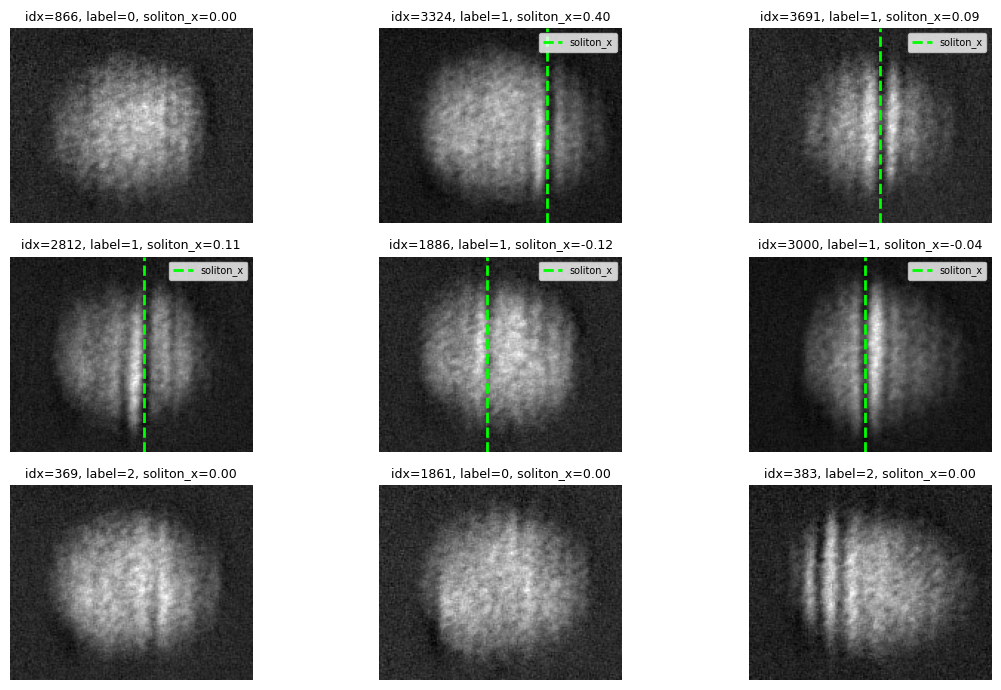

In [8]:
# Visualize a few training images and check soliton_x label vs. image
rng = np.random.default_rng(SEED)
idx = rng.choice(len(train_images_for_check), size=min(9, len(train_images_for_check)), replace=False)

fig, axes = plt.subplots(3, 3, figsize=(12, 7))
axes = axes.flatten()

for ax, i in zip(axes, idx):
    im = to_uint8_from_minus1_1(train_images_for_check[i])
    ax.imshow(im, cmap="gray", vmin=0, vmax=255)
    label = train_labels_for_check[i]
    soliton_x = train_soliton_xs_for_check[i]
    ax.set_title(f"idx={i}, label={label}, soliton_x={soliton_x:.2f}", fontsize=9)
    ax.axis("off")
    # For class 1, overlay soliton position
    if label == 1:
        # Map soliton_x in [-1,1] to pixel position
        x_px = int((soliton_x + 1) / 2 * (im.shape[1] - 1))
        ax.axvline(x_px, color="lime", linestyle="--", linewidth=2, label="soliton_x")
        ax.legend(fontsize=7, loc="upper right")

for i in range(len(idx), len(axes)):
    axes[i].axis("off")

plt.tight_layout()
plt.show()


## Convolutional conditional GAN

This section defines a convolutional conditional GAN for grayscale 164x132 images.

- Generator: latent + condition -> feature map upsampling -> image tensor in [-1, 1]
- Discriminator: image + condition map -> convolutional downsampling -> real/fake probability
- Training: standard BCE adversarial loss

In [9]:
LATENT_DIM = 100
COND_DIM = 5  # 3 (one-hot label) + 1 (position) + 1 (quality)

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
image_dim = IMAGE_HEIGHT * IMAGE_WIDTH

class Generator(nn.Module):
    def __init__(self, z_dim: int, c_dim: int):
        super().__init__()
        self.z_dim = z_dim
        self.c_dim = c_dim

        # 1. Map concatenated (z, c) to exactly 33x41x256
        self.fc = nn.Sequential(
            nn.Linear(z_dim + c_dim, 256 * 33 * 41),
            nn.BatchNorm1d(256 * 33 * 41), # Added batch norm for stability
            nn.LeakyReLU(0.2, inplace=True),
        )

        self.upsample_blocks = nn.Sequential(
            # 33x41 -> 66x82
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            # 66x82 -> 132x164
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2, inplace=True),

            # Final conv to 1 channel (maintains 132x164)
            nn.Conv2d(64, 1, kernel_size=3, stride=1, padding=1),
            nn.Tanh(),
        )

    def forward(self, z: torch.Tensor, c: torch.Tensor) -> torch.Tensor:
        # Concatenate latent noise and condition
        x = torch.cat([z, c], dim=1)
        x = self.fc(x)
        # Reshape to spatial tensor: (Batch, Channels, Height, Width)
        x = x.view(-1, 256, 33, 41)
        x = self.upsample_blocks(x)
        return x


class Discriminator(nn.Module):
    def __init__(self, c_dim: int):
        super().__init__()
        
        self.features = nn.Sequential(
            # Layer 1: No normalization is standard for the first layer
            nn.Conv2d(1 + c_dim, 64, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout2d(0.3),

            # Layer 2: Use InstanceNorm instead of BatchNorm
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.InstanceNorm2d(128, affine=True), 
            nn.LeakyReLU(0.2, inplace=True),
            
            # Layer 3: Use InstanceNorm
            nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=0),
            nn.InstanceNorm2d(256, affine=True),
            nn.LeakyReLU(0.2, inplace=True),
        )
                
        with torch.no_grad():
            dummy = torch.zeros(1, 1 + c_dim, IMAGE_HEIGHT, IMAGE_WIDTH)
            feat_dim = self.features(dummy).view(1, -1).size(1)

        self.linear = nn.Linear(feat_dim, 1)

    def forward(self, x, c):
        if c.dim() > 2: c = c.view(c.size(0), -1) 
        if x.dim() == 3: x = x.unsqueeze(1)
        if x.dim() == 5: x = x.squeeze(1)

        c_map = c.view(c.size(0), c.size(1), 1, 1).expand(-1, -1, x.size(2), x.size(3))
        x_combined = torch.cat([x, c_map], dim=1)

        feats = self.features(x_combined)
        return self.linear(feats.view(feats.size(0), -1))

# --- Initialization ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

G = Generator(z_dim=LATENT_DIM, c_dim=COND_DIM).to(device)
D = Discriminator(c_dim=COND_DIM).to(device)

LEARNING_RATE = 5e-5
opt_g = torch.optim.Adam(G.parameters(), lr=LEARNING_RATE, betas=(0.0, 0.9))
opt_d = torch.optim.Adam(D.parameters(), lr=LEARNING_RATE, betas=(0.0, 0.9))

In [11]:
def compute_gradient_penalty(D, real_samples, fake_samples, conditions, device):
    """Calculates the gradient penalty loss for WGAN GP"""
    # Random weight term for interpolation between real and fake samples
    alpha = torch.rand((real_samples.size(0), 1, 1, 1)).to(device)
    
    # Get random interpolation between real and fake samples
    interpolates = (alpha * real_samples + ((1 - alpha) * fake_samples)).requires_grad_(True)
    
    d_interpolates = D(interpolates, conditions)
    fake = torch.ones(real_samples.shape[0], 1).to(device)
    
    # Get gradient w.r.t. interpolates
    gradients = torch.autograd.grad(
        outputs=d_interpolates,
        inputs=interpolates,
        grad_outputs=fake,
        create_graph=True,
        retain_graph=True,
        only_inputs=True,
    )[0]
    
    gradients = gradients.view(gradients.size(0), -1)
    gradient_penalty = ((gradients.norm(2, dim=1) - 1) ** 2).mean()
    return gradient_penalty

In [ ]:
import torch
from tqdm import tqdm

LAMBDA_GP = 10  # Standard value for gradient penalty weight

def train_step(G, D, opt_g, opt_d, real_images, conditions, latent_dim, device, d_steps=5):
    batch_size = real_images.size(0)
    
    for i in range(d_steps):
        # ---------------------
        #  Train Discriminator
        # ---------------------
        opt_d.zero_grad()
        
        # 1. Generate fake images
        z = torch.randn(batch_size, latent_dim).to(device)
        fake_images = G(z, conditions)
        
        # 2. Get Critic scores
        real_validity = D(real_images, conditions)
        fake_validity = D(fake_images.detach(), conditions)
        
        # 3. Gradient Penalty
        gp = compute_gradient_penalty(D, real_images, fake_images.detach(), conditions, device)
        
        # 4. Wasserstein Loss: Minimize (Fake Score - Real Score) + GP
        # Apparently WGAN is good for interpolating between classes, which is what we want to do with the soliton position and quality labels
        # We want Real Score to be high and Fake Score to be low
        d_loss = -torch.mean(real_validity) + torch.mean(fake_validity) + LAMBDA_GP * gp
        
        d_loss.backward()
        opt_d.step()
        
    # -----------------
    #  Train Generator 
    # -----------------
    opt_g.zero_grad()
    
    # We want to maximize the Discriminator's score for fake images
    gen_fake_validity = D(fake_images, conditions)
    g_loss = -torch.mean(gen_fake_validity)
    
    g_loss.backward()
    opt_g.step()
    
    return d_loss.item(), g_loss.item()

In [13]:
def train_model(G, D, dataloader, opt_g, opt_d, epochs, latent_dim, device):
    G.train()
    D.train()
    
    for epoch in range(epochs):
        d_losses = []
        g_losses = []
        
        loop = tqdm(dataloader, leave=True)

        for images, conds, _ in loop:
            
            real_images = images.to(device).view(-1, 1, 132, 164).float() 
            conditions = conds.to(device).view(-1, 5).float()
            
            d_loss, g_loss = train_step(
                G, D, opt_g, opt_d, 
                real_images, conditions, 
                latent_dim, device
            )
            
            d_losses.append(d_loss)
            g_losses.append(g_loss)
            
            loop.set_description(f"Epoch [{epoch+1}/{epochs}]")
            loop.set_postfix(d_loss=f"{d_loss:.4f}", g_loss=f"{g_loss:.4f}")
            
        avg_d = sum(d_losses)/len(d_losses)
        avg_g = sum(g_losses)/len(g_losses)
        print(f"Epoch {epoch+1} Avg Loss: D: {avg_d:.4f}, G: {avg_g:.4f}")

    return {"G_loss": g_losses, "D_loss": d_losses}

In [14]:
EPOCHS = 25

train_state = train_model(G, D, train_loader, opt_g, opt_d, EPOCHS, LATENT_DIM, device)

  0%|          | 0/268 [00:00<?, ?it/s]c:\Users\sbrad\.conda\envs\soldet_reproduce\lib\site-packages\torch\autograd\graph.py:825: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\cuda\CublasHandlePool.cpp:135.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
Epoch [1/25]: 100%|██████████| 268/268 [05:21<00:00,  1.20s/it, d_loss=-31.3643, g_loss=-280.3743]


Epoch 1 Avg Loss: D: -67.9542, G: -114.6656


Epoch [2/25]: 100%|██████████| 268/268 [05:05<00:00,  1.14s/it, d_loss=-12.2830, g_loss=-277.2856]


Epoch 2 Avg Loss: D: -19.8978, G: -291.8012


Epoch [3/25]: 100%|██████████| 268/268 [05:06<00:00,  1.14s/it, d_loss=-8.0957, g_loss=-235.5723] 


...

Epoch 23 Avg Loss: D: -6.8339, G: -4.3298


Epoch [24/25]: 100%|██████████| 268/268 [05:06<00:00,  1.14s/it, d_loss=-13.7126, g_loss=-3.7714] 


Epoch 24 Avg Loss: D: -6.9825, G: 6.4005


Epoch [25/25]: 100%|██████████| 268/268 [05:05<00:00,  1.14s/it, d_loss=-9.9304, g_loss=20.9567]  

Epoch 25 Avg Loss: D: -6.7930, G: 1.4096


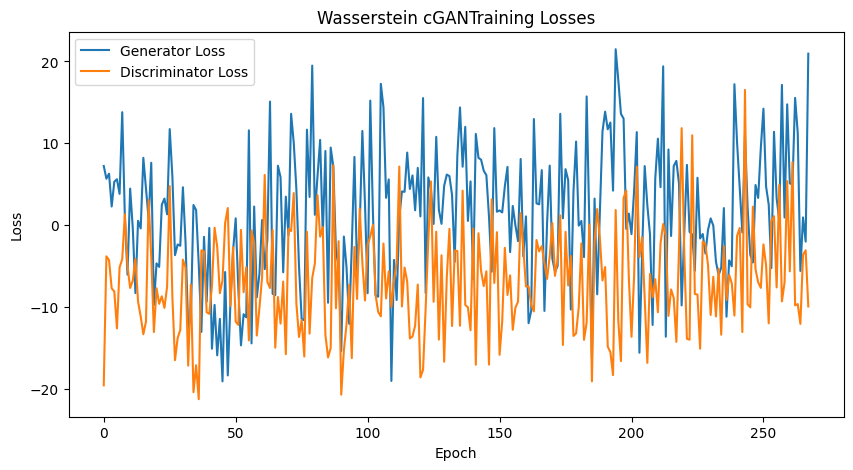

In [19]:
# plot training losses
plt.figure(figsize=(10, 5))
plt.plot(train_state["G_loss"], label="Generator Loss")
plt.plot(train_state["D_loss"], label="Discriminator Loss")
plt.title("Wasserstein cGANTraining Losses")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [20]:
def sample_generator(num_images: int, seed: int, cond: np.ndarray) -> torch.Tensor:
    torch.manual_seed(seed)
    z = torch.randn((num_images, LATENT_DIM), device=device)
    c = np.tile(cond[None, :], (num_images, 1)).astype(np.float32)
    c_t = torch.from_numpy(c).to(device)
    with torch.no_grad():
        out = G(z, c_t)
    return out

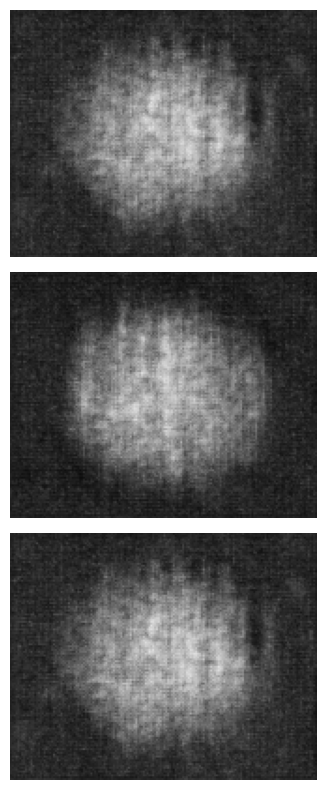

In [30]:
c0 = cond_vector(label=0)
c1 = cond_vector(label=1, soliton_x=0.5, quality=1.0)
c2 = cond_vector(label=2)

out0 = sample_generator(num_images=2, seed=123, cond=c0)
out1 = sample_generator(num_images=2, seed=123, cond=c1)
out2 = sample_generator(num_images=2, seed=123, cond=c2)
out = torch.cat([out0, out1, out2], dim=0)

fig, axes = plt.subplots(3, 1, figsize=(10, 8))
axes = axes.flatten()
imgs = out.detach().cpu().numpy()
for i, ax in enumerate(axes):
    ax.imshow(to_uint8_from_minus1_1(imgs[i, 0]), cmap="gray", vmin=0, vmax=255)
    ax.axis("off")
plt.tight_layout()
plt.show()

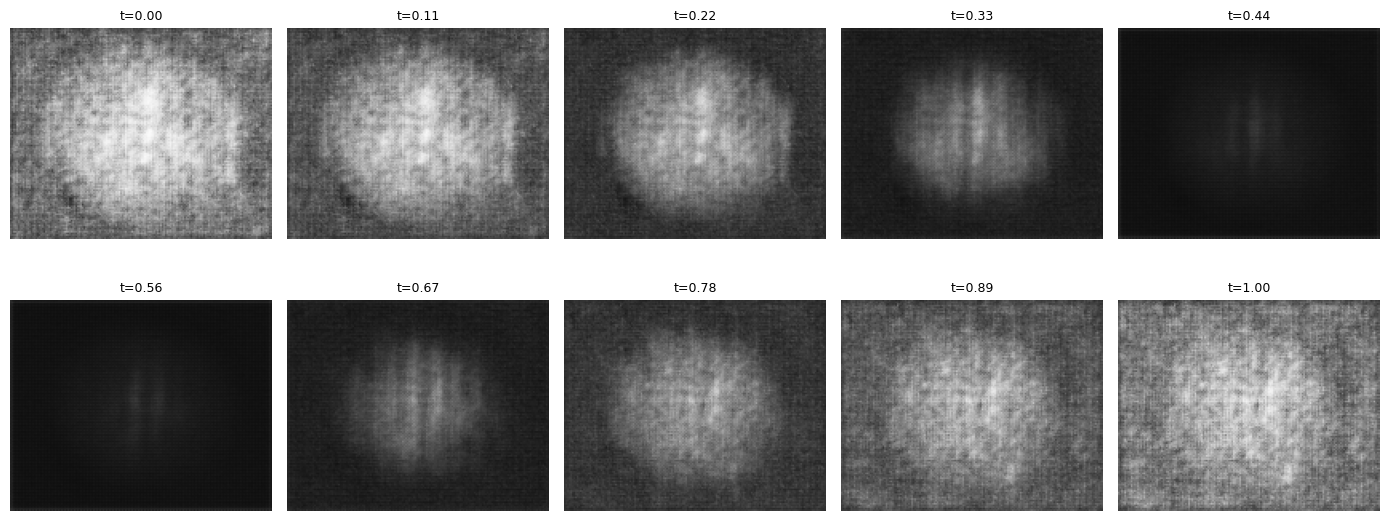

In [22]:
torch.manual_seed(7)
z0 = torch.randn((1, LATENT_DIM), device=device)
z1 = torch.randn((1, LATENT_DIM), device=device)
alphas = torch.linspace(0, 1, steps=10, device=device).view(-1, 1)
z_interp = (1 - alphas) * z0 + alphas * z1

cond = cond_vector(label=1, soliton_x=0.0, quality=1.0)
c = np.tile(cond[None, :], (10, 1)).astype(np.float32)
c_t = torch.from_numpy(c).to(device)

with torch.no_grad():
    imgs = G(z_interp, c_t)

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
axes = axes.flatten()
arr = imgs.detach().cpu().numpy()
for i, ax in enumerate(axes):
    ax.imshow(to_uint8_from_minus1_1(arr[i, 0]), cmap="gray", vmin=0, vmax=255)
    ax.set_title(f"t={i/9:.2f}", fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()

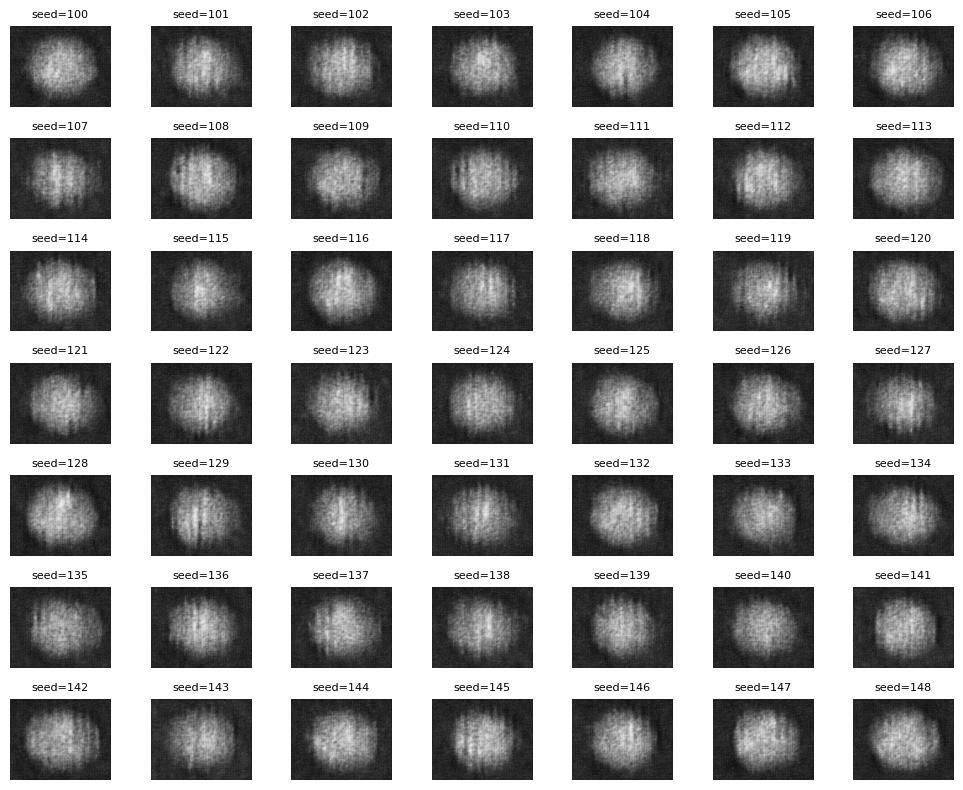

In [25]:
all_imgs = []
cond = cond_vector(label=1, soliton_x=0, quality=1.0)

for seed in range(100, 150):
    imgs = sample_generator(num_images=2, seed=seed, cond=cond)
    all_imgs.append(imgs[0, 0].detach().cpu().numpy())

fig, axes = plt.subplots(7, 7, figsize=(10, 8))
axes = axes.flatten()
for i, ax in enumerate(axes):
    ax.imshow(to_uint8_from_minus1_1(all_imgs[i]), cmap="gray", vmin=0, vmax=255)
    ax.set_title(f"seed={100 + i}", fontsize=8)
    ax.axis("off")
plt.tight_layout()
plt.show()